# CRYOWRF validation of blowing-snow mass flux

| Section | Observations | WRF variable |
|---------|--------------|--------------|
| 1–4 | FlowCapt FC4, SPC | BS_QI_DRIFT + saltation BC |
| 5 | Ceilometer | column BS_QI |
| 7 | FlowCapt, SPC vs wind | BS_QI_DRIFT + VW_SFC |
| 8 | FlowCapt, SPC vs u* | BS_QI_DRIFT + UST |
| 9 | – | SN_VOLI, SN_VOLW (snow density) |

Instrument heights are event-specific; fine-mesh level heights (`SN_C_HEIGHT`) are read at every
timestep. All functions are in `dbs_utils.py`.

In [ ]:
# ── Run switches ─────────────────────────────────────────────────────────────
SIM_KEY    = "trans_syn"   # event used when RUN_ALL is False
RUN_ALL    = True          # True -> run every event; False -> only SIM_KEY
SAVE_PLOTS = True          # True -> write figures to OUTPUT_DIR
DOMAIN     = "d05"

import importlib
import dbs_utils as ru
importlib.reload(ru)

RUN_KEYS = ru.get_run_keys(SIM_KEY, RUN_ALL)
print("Events to run:", RUN_KEYS)
print("Save figures :", SAVE_PLOTS)


Events to run: ['cold_kat', 'trans_syn', 'warm_syn']
Save figures : True


In [6]:
# Cut the yearly SPC pickles to the event windows BEFORE any WRF data is loaded
# (reading the full files later, with WRF data in memory, raises MemoryError).
# The first run writes D:\data\spc<year>_events.pkl; later runs only read that file.
import gc
for f in sorted({ru.SIMULATIONS[k]["spc_file"] for k in RUN_KEYS}):
    print(f, "->", len(ru.load_spc_events(f)), "rows")
gc.collect()


SPC: cut spc2024.pkl to the event windows (5101 rows) -> D:\data\spc2024_events.pkl
D:\data\spc2024.pkl -> 5101 rows
SPC: cut spc2025.pkl to the event windows (6181 rows) -> D:\data\spc2025_events.pkl
D:\data\spc2025.pkl -> 6181 rows


0

## 1–4. Mass flux (FlowCapt / SPC, saltation BC)

In [7]:
bs_events = {}
for key in RUN_KEYS:
    print(f"\n{'='*60}\n  {key} - {ru.SIMULATIONS[key]['label']}\n{'='*60}")
    bs_events[key] = ru.build_bs_event(key, domain=DOMAIN)
    ru.print_bs_metrics(bs_events[key])



  cold_kat - Cold katabatic - May 2024


c:\Users\lory2\Desktop\thesis_codes\04_cryowrf_validation\funcs_interp_vars.py:1210: RuntimeWarning: invalid value encountered in divide
  r_mean = np.where(N_total > 0, r_accum / N_total, np.nan)


  Quantity                                 N       MAE      Bias       r
  FC                                      38    49.260   -37.977   0.574
  SPC (@ 0.60 m)                          38    99.189   -96.781   0.523

  trans_syn - Transitional synoptic - Apr 2025


c:\Users\lory2\Desktop\thesis_codes\04_cryowrf_validation\funcs_interp_vars.py:1210: RuntimeWarning: invalid value encountered in divide
  r_mean = np.where(N_total > 0, r_accum / N_total, np.nan)


  Quantity                                 N       MAE      Bias       r
  FC                                      20    25.384   -24.557  -0.096
  SPC (@ 0.49 m)                          20    34.599   -33.916  -0.115

  warm_syn - Warm synoptic - Apr 2025
  Quantity                                 N       MAE      Bias       r
  FC                                      24    10.331    -7.052   0.382
  SPC (@ 0.49 m)                          24    21.905   -20.703   0.372


c:\Users\lory2\Desktop\thesis_codes\04_cryowrf_validation\funcs_interp_vars.py:1210: RuntimeWarning: invalid value encountered in divide
  r_mean = np.where(N_total > 0, r_accum / N_total, np.nan)


### Per-event time series and scatter

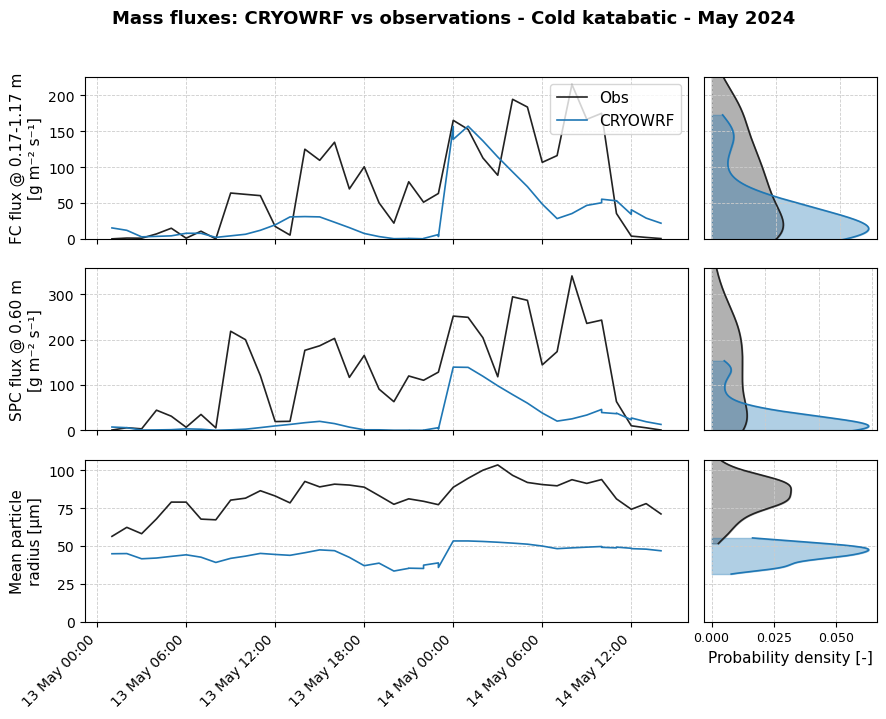

Saved: C:\Users\lory2\Desktop\tesi\wrf_notebooks\validation_plots\bs_scatter_d04_cold_kat.png


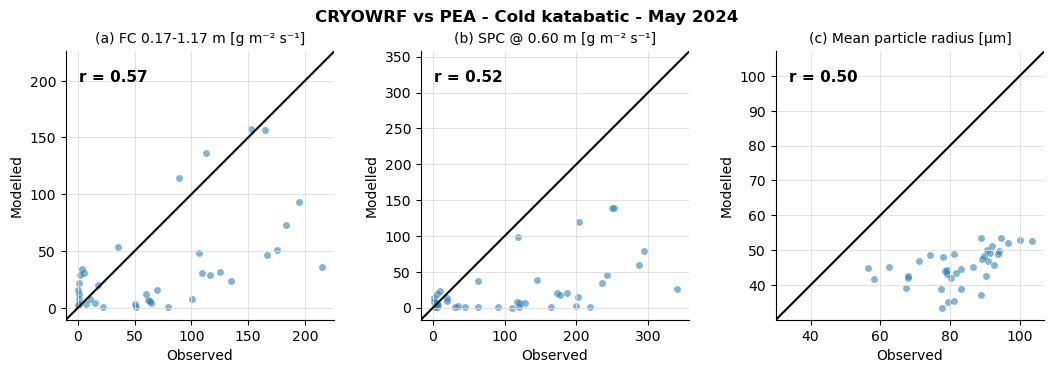

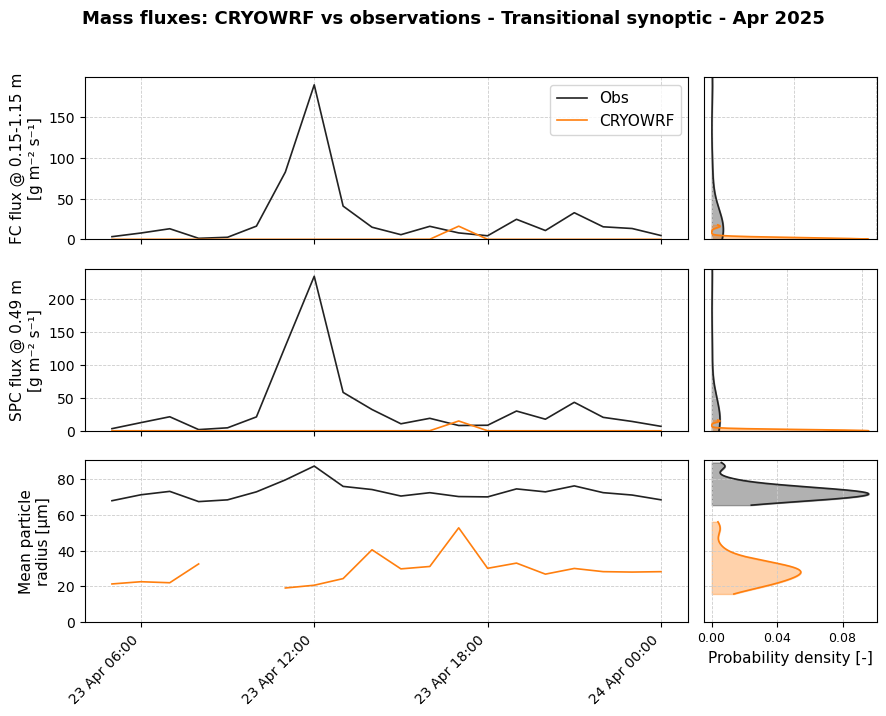

Saved: C:\Users\lory2\Desktop\tesi\wrf_notebooks\validation_plots\bs_scatter_d04_trans_syn.png


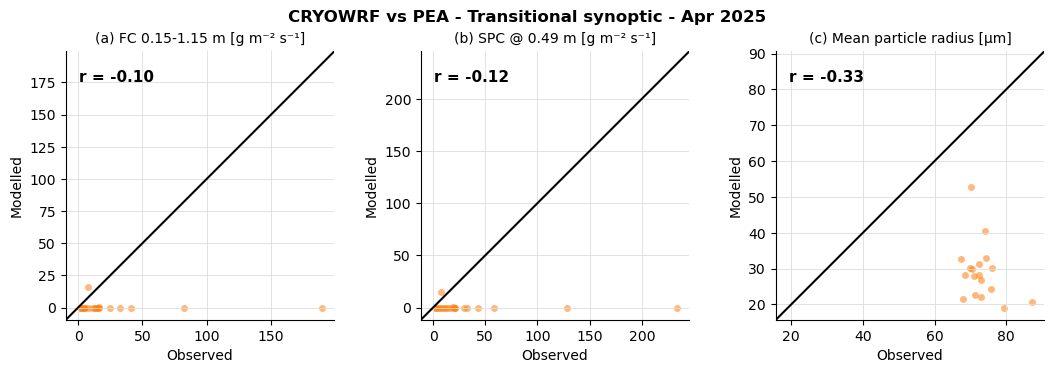

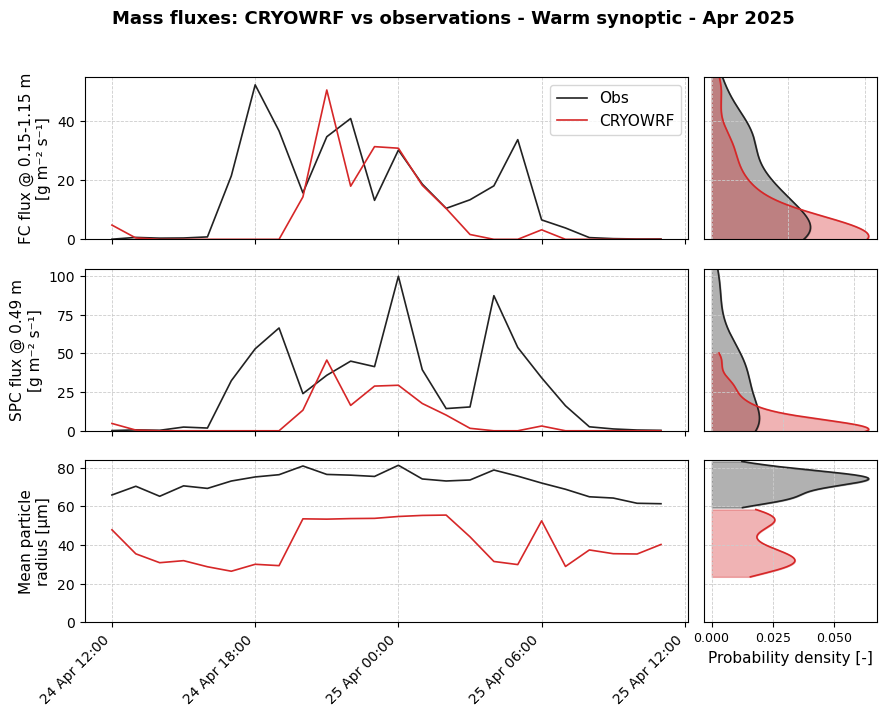

Saved: C:\Users\lory2\Desktop\tesi\wrf_notebooks\validation_plots\bs_scatter_d04_warm_syn.png


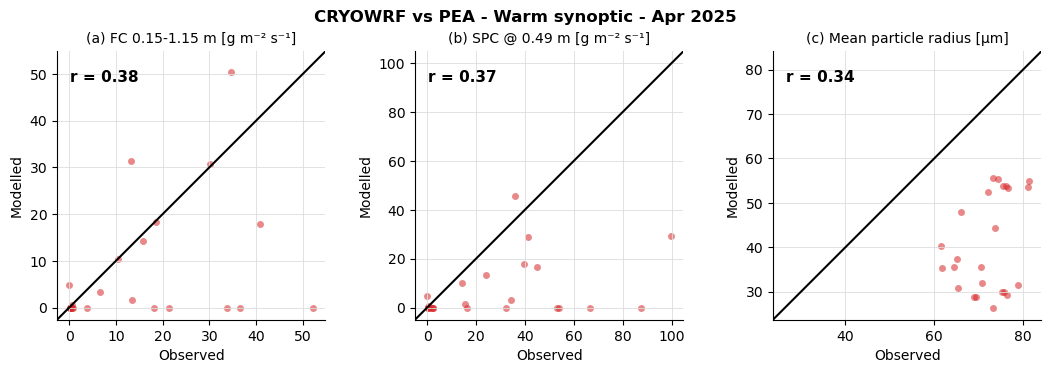

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
#  Per-event time series (FC / SPC flux + optional mean radius) with marginal PDFs.
#  Per-event scatter: ru.plot_bs_scatter.
# ══════════════════════════════════════════════════════════════════════════════
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator, ScalarFormatter

# ── Style ────────────────────────────────────────────
PLOT_MEANR   = True        # True to add the mean radius panel
COLOR_OBS    = "#222222"
MODEL_COLORS = {"cold_kat": "#1f77b4", "trans_syn": "#ff7f0e", "warm_syn": "#d62728"}
MODEL_COLOR_DEFAULT = "#1f77b4"
LW_OBS       = 1.2
LW_MOD       = 1.2
ALPHA_PDF    = 0.35
TICK_FS      = 11
PDF_XTICKS   = 3            # number of x ticks on the PDF panels
TITLE_FS     = 13
PANEL_W      = 9.0         # figure width
PANEL_H      = 2.3          # height of each panel
GRID_COLOR   = "#cccccc"
GRID_LW      = 0.6
SAVE_FIG     = SAVE_PLOTS
DPI          = 180
# ──────────────────────────────────────────────────────────────────────────────

for key in RUN_KEYS:
    ev = bs_events[key]
    mc = MODEL_COLORS.get(key, MODEL_COLOR_DEFAULT)

    panels = [
        (ev["obs_fc"],  ev["mod_fc_salt"],  f"FC flux @ {ev['fc_lo']:.2f}-{ev['fc_hi']:.2f} m\n[{ru.FLUX_UNIT}]"),
        (ev["obs_spc"], ev["mod_spc_salt"], f"SPC flux @ {ev['spc_z']:.2f} m\n[{ru.FLUX_UNIT}]"),
    ]
    if PLOT_MEANR:
        panels.append((ev["obs_meanr"], ev["mod_meanr"], "Mean particle\nradius [µm]"))
    n = len(panels)

    fig = plt.figure(figsize=(PANEL_W, PANEL_H * n))
    gs  = gridspec.GridSpec(n, 2, width_ratios=[3.5, 1], hspace=0.18, wspace=0.04,
                            top=0.90, bottom=0.11, left=0.09, right=0.97)
    ax_ts  = [fig.add_subplot(gs[r, 0]) for r in range(n)]
    ax_pdf = [fig.add_subplot(gs[r, 1]) for r in range(n)]
    for i in range(1, n):
        ax_ts[i].sharex(ax_ts[0])
    for r in range(n):
        ax_pdf[r].sharey(ax_ts[r])

    for r, (obs_s, mod_s, ylabel) in enumerate(panels):
        ax = ax_ts[r]
        ax.plot(obs_s.index, obs_s.values, color=COLOR_OBS, lw=LW_OBS, label="Obs")
        ax.plot(mod_s.index, mod_s.values, color=mc, lw=LW_MOD, label="CRYOWRF")
        ax.set_ylabel(ylabel, fontsize=TICK_FS); ax.set_ylim(bottom=0)
        ax.grid(True, color=GRID_COLOR, lw=GRID_LW, ls="--")
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b %H:%M"))
        ax.xaxis.set_major_locator(mdates.HourLocator(byhour=[0, 6, 12, 18]))
        if r < n - 1:
            plt.setp(ax.get_xticklabels(), visible=False)
        else:
            plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
        ax_p = ax_pdf[r]
        for data, color in [(obs_s, COLOR_OBS), (mod_s, mc)]:
            x, y = ru.kde_curve(data)
            if len(x):
                ax_p.fill_betweenx(x, y, alpha=ALPHA_PDF, color=color)
                ax_p.plot(y, x, color=color, lw=1.2)
        ax_p.grid(True, color=GRID_COLOR, lw=GRID_LW, ls="--")
        ax_p.tick_params(axis="y", left=False, right=False, labelleft=False, labelright=False)
        if r < n - 1:
            ax_p.tick_params(axis="x", bottom=False, labelbottom=False)
        else:
            ax_p.tick_params(axis="x", labelsize=9)
            ax_p.xaxis.set_major_locator(MaxNLocator(nbins=PDF_XTICKS, prune="both"))
            _fmt = ScalarFormatter(useMathText=True)
            ax_p.xaxis.set_major_formatter(_fmt)
            ax_p.set_xlabel("Probability density [-]", size=TICK_FS)

    ax_ts[0].legend(fontsize=TICK_FS, loc="upper right")
    fig.suptitle(f"Mass fluxes: CRYOWRF vs observations - {ev['label']}",
                 fontsize=TITLE_FS, fontweight="bold", y=0.998)
    if SAVE_FIG:
        fig.savefig(os.path.join(ru.OUTPUT_DIR, f"bs_timeseries_{DOMAIN}_{key}.png"),
                    dpi=DPI, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    # per-event obs-vs-model scatter
    ru.plot_bs_scatter(bs_events[key], domain=DOMAIN, save=SAVE_PLOTS)


### Combined scatter and statistics

Mass fluxes (SPC and FlowCapt) pooled across events; mean particle radius in a separate scatter. Table metrics: MAE, bias, r, PBIAS % = 100·Σ(mod−obs)/Σ(obs), NRMSE % = 100·RMSE/mean(obs).

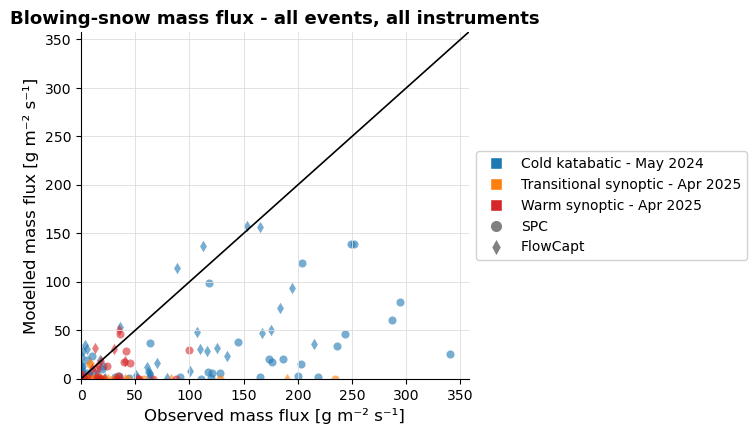

Saved: C:\Users\lory2\Desktop\tesi\wrf_notebooks\validation_plots\bs_meanr_scatter_all_events_d04.png


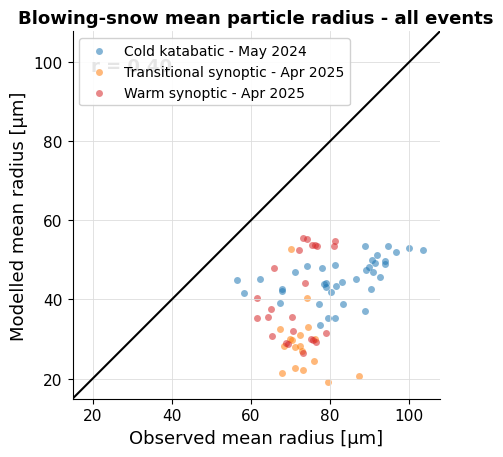


-- FC 0.17-1.17 m [g m⁻² s⁻¹] --


,Event,N,MAE,Bias,PBIAS %,NRMSE %,r
0,Cold katabatic - May 2024,38,49.26,-37.977,-52.1,89.9,0.574
1,OVERALL,38,49.26,-37.977,-52.1,89.9,0.574



-- SPC @ 0.60 m [g m⁻² s⁻¹] --


,Event,N,MAE,Bias,PBIAS %,NRMSE %,r
0,Cold katabatic - May 2024,38,99.189,-96.781,-78.3,104.1,0.523
1,OVERALL,38,99.189,-96.781,-78.3,104.1,0.523



-- FC 0.15-1.15 m [g m⁻² s⁻¹] --


,Event,N,MAE,Bias,PBIAS %,NRMSE %,r
0,Transitional synoptic - Apr 2025,20,25.384,-24.557,-96.8,192.7,-0.096
1,Warm synoptic - Apr 2025,24,10.331,-7.052,-47.9,118.4,0.382
2,OVERALL,44,17.173,-15.009,-76.8,180.9,0.054



-- SPC @ 0.49 m [g m⁻² s⁻¹] --


,Event,N,MAE,Bias,PBIAS %,NRMSE %,r
0,Transitional synoptic - Apr 2025,20,34.599,-33.916,-97.8,183.4,-0.115
1,Warm synoptic - Apr 2025,24,21.905,-20.703,-74.4,120.2,0.372
2,OVERALL,44,27.675,-26.709,-86.3,159.9,0.122



-- Mean particle radius [µm] --


,Event,N,MAE,Bias,r
0,Cold katabatic - May 2024,38,37.4,-37.4,0.503
1,Transitional synoptic - Apr 2025,18,44.1,-44.1,-0.332
2,Warm synoptic - Apr 2025,24,31.3,-31.3,0.345
3,OVERALL,80,37.1,-37.1,0.401


In [9]:
# ══════════════════════════════════════════════════════════════════════════════
#  Pooled mass-flux scatter (all events, both instruments), legend outside the axes.
# ══════════════════════════════════════════════════════════════════════════════
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ── Style ────────────────────────────────────────────
FIGSIZE      = (5, 4.5)
MODEL_COLORS = {"cold_kat": "#1f77b4", "trans_syn": "#ff7f0e", "warm_syn": "#d62728"}
MODEL_COLOR_DEFAULT = "#1f77b4"
MARKER_SPC   = "o"
MARKER_FC    = "d"
MARKER_SIZE  = 34
MARKER_ALPHA = 0.6
ONE2ONE      = dict(color="k", lw=1.2)      # 1:1 line style
LABEL_FS     = 12
TITLE_FS     = 13
TICK_FS      = 10
LEGEND_FS    = 10
LEGEND_LOC   = "center left"                # legend outside: anchor + bbox
LEGEND_BBOX  = (1.02, 0.5)                  # x > 1 -> right of the axes
SAVE_FIG     = SAVE_PLOTS
DPI          = 180
# ──────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=FIGSIZE)
all_x, all_y = [], []
for key, ev in bs_events.items():
    col = MODEL_COLORS.get(key, MODEL_COLOR_DEFAULT)
    for obs_s, mod_s, marker in [
        (ev["obs_fc"],  ev["mod_fc_salt"],  MARKER_FC),
        (ev["obs_spc"], ev["mod_spc_salt"], MARKER_SPC),
    ]:
        x, y = ru._finite_pair(obs_s, mod_s)
        if not len(x):
            continue
        all_x.append(x); all_y.append(y)
        ax.scatter(x, y, color=col, marker=marker, s=MARKER_SIZE, alpha=MARKER_ALPHA, linewidths=0)

if all_x:
    lim = max(np.concatenate(all_x).max(), np.concatenate(all_y).max()) * 1.05
    ax.plot([0, lim], [0, lim], **ONE2ONE)
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)

ax.set_xlabel(f"Observed mass flux [{ru.FLUX_UNIT}]", fontsize=LABEL_FS)
ax.set_ylabel(f"Modelled mass flux [{ru.FLUX_UNIT}]", fontsize=LABEL_FS)
ax.set_title("Blowing-snow mass flux - all events, all instruments",
             fontsize=TITLE_FS, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(color="#dddddd", lw=0.6, zorder=0)
ax.tick_params(labelsize=TICK_FS)

# legend: colours = events, markers = instruments
event_handles = [Line2D([0], [0], marker="s", color="w",
                        markerfacecolor=MODEL_COLORS.get(k, MODEL_COLOR_DEFAULT), markersize=9,
                        label=ru.SIMULATIONS[k]["label"]) for k in bs_events]
instr_handles = [
    Line2D([0], [0], marker=MARKER_SPC, color="w", markerfacecolor="gray", markersize=9, label="SPC"),
    Line2D([0], [0], marker=MARKER_FC,  color="w", markerfacecolor="gray", markersize=9, label="FlowCapt"),
]
ax.legend(handles=event_handles + instr_handles, fontsize=LEGEND_FS,
          loc=LEGEND_LOC, bbox_to_anchor=LEGEND_BBOX, framealpha=0.9, borderaxespad=0.0)

if SAVE_FIG:
    fig.savefig(os.path.join(ru.OUTPUT_DIR, f"bs_flux_scatter_all_events_{DOMAIN}.png"),
                dpi=DPI, bbox_inches="tight")
plt.show()
plt.close(fig)

# radius scatter + statistics tables
ru.plot_bs_meanr_scatter_all(bs_events, domain=DOMAIN, save=SAVE_PLOTS)
ru.show_tables(ru.bs_stats_tables(bs_events))
ru.show_tables(ru.bs_meanr_stats(bs_events))   # mean-radius statistics (flux > 0 and radius > 0)

### Mass-flux underestimation

In [10]:
# ── Mass-flux underestimation [%], per event and pooled over the three events ──
import numpy as np, pandas as pd

def bs_underestimation(events):
    """Underestimation of the modelled mass flux relative to observations.

    underest_% = 100*(mean_obs - mean_mod)/mean_obs over paired samples.
    Returns a DataFrame with: Model, Event, Quantity, N, mean_obs, mean_mod,
    bias, underest_%. Quantity in {FC, SPC, FC+SPC}; Event = "ALL EVENTS"
    is the pool over the three events.
    """
    MODELS = [("salt BC",  "mod_fc_salt", "mod_spc_salt")]
    rows = []
    for mlabel, fc_key, spc_key in MODELS:
        # pooled over the three events, per quantity
        pool = {"FC": ([], []), "SPC": ([], []), "FC+SPC": ([], [])}

        def add_row(event_label, qty, o, m):
            if len(o) == 0:
                rows.append({"Model": mlabel, "Event": event_label,
                             "Quantity": qty, "N": 0, "mean_obs": np.nan,
                             "mean_mod": np.nan, "bias": np.nan,
                             "underest_%": np.nan})
                return
            mo, mm = float(np.mean(o)), float(np.mean(m))
            rows.append({"Model": mlabel, "Event": event_label, "Quantity": qty,
                         "N": len(o), "mean_obs": round(mo, 3),
                         "mean_mod": round(mm, 3), "bias": round(mm - mo, 3),
                         "underest_%": round(100.0 * (mo - mm) / mo, 1)})

        for key, ev in events.items():
            o_fc,  m_fc  = ru._finite_pair(ev["obs_fc"],  ev[fc_key])
            o_spc, m_spc = ru._finite_pair(ev["obs_spc"], ev[spc_key])
            o_both = np.concatenate([o_fc, o_spc])
            m_both = np.concatenate([m_fc, m_spc])
            add_row(ev["label"], "FC",     o_fc,  m_fc)
            add_row(ev["label"], "SPC",    o_spc, m_spc)
            add_row(ev["label"], "FC+SPC", o_both, m_both)
            for q, o, m in [("FC", o_fc, m_fc), ("SPC", o_spc, m_spc),
                            ("FC+SPC", o_both, m_both)]:
                pool[q][0].append(o); pool[q][1].append(m)

        for q in ["FC", "SPC", "FC+SPC"]:
            o = np.concatenate(pool[q][0]); m = np.concatenate(pool[q][1])
            add_row("ALL EVENTS", q, o, m)

    return pd.DataFrame(rows)

bs_underest = bs_underestimation(bs_events)

# print by model, then FC / SPC / FC+SPC
for mlabel in ["original", "salt BC"]:
    print(f"\n{'='*72}\n  Blowing-snow mass underestimation - model: {mlabel}\n{'='*72}")
    sub = bs_underest[bs_underest["Model"] == mlabel]
    for q in ["FC", "SPC", "FC+SPC"]:
        print(f"\n  -- {q} --")
        t = sub[sub["Quantity"] == q][["Event", "N", "mean_obs",
                                       "mean_mod", "bias", "underest_%"]]
        print(t.to_string(index=False))

try:
    ru.show_tables({"Blowing-snow mass underestimation [%]": bs_underest})
except Exception:
    pass
bs_underest



  Blowing-snow mass underestimation - model: original

  -- FC --
Empty DataFrame
Columns: [Event, N, mean_obs, mean_mod, bias, underest_%]
Index: []

  -- SPC --
Empty DataFrame
Columns: [Event, N, mean_obs, mean_mod, bias, underest_%]
Index: []

  -- FC+SPC --
Empty DataFrame
Columns: [Event, N, mean_obs, mean_mod, bias, underest_%]
Index: []

  Blowing-snow mass underestimation - model: salt BC

  -- FC --
                           Event  N  mean_obs  mean_mod    bias  underest_%
       Cold katabatic - May 2024 38    72.950    34.973 -37.977        52.1
Transitional synoptic - Apr 2025 20    25.371     0.814 -24.557        96.8
        Warm synoptic - Apr 2025 24    14.709     7.656  -7.052        47.9
                      ALL EVENTS 82    44.299    18.646 -25.653        57.9

  -- SPC --
                           Event  N  mean_obs  mean_mod    bias  underest_%
       Cold katabatic - May 2024 38   123.562    26.781 -96.781        78.3
Transitional synoptic - Apr 2025 20    34

,Model,Event,Quantity,N,mean_obs,mean_mod,bias,underest_%
0,salt BC,Cold katabatic - May 2024,FC,38,72.950,34.973,-37.977,52.1
1,salt BC,Cold katabatic - May 2024,SPC,38,123.562,26.781,-96.781,78.3
2,salt BC,Cold katabatic - May 2024,FC+SPC,76,98.256,30.877,-67.379,68.6
3,salt BC,Transitional synoptic - Apr 2025,FC,20,25.371,0.814,-24.557,96.8
4,salt BC,Transitional synoptic - Apr 2025,SPC,20,34.662,0.746,-33.916,97.8
5,salt BC,Transitional synoptic - Apr 2025,FC+SPC,40,30.017,0.780,-29.237,97.4
6,salt BC,Warm synoptic - Apr 2025,FC,24,14.709,7.656,-7.052,47.9
7,salt BC,Warm synoptic - Apr 2025,SPC,24,27.841,7.138,-20.703,74.4
8,salt BC,Warm synoptic - Apr 2025,FC+SPC,48,21.275,7.397,-13.877,65.2
9,salt BC,ALL EVENTS,FC,82,44.299,18.646,-25.653,57.9


,Model,Event,Quantity,N,mean_obs,mean_mod,bias,underest_%
0,salt BC,Cold katabatic - May 2024,FC,38,72.950,34.973,-37.977,52.1
1,salt BC,Cold katabatic - May 2024,SPC,38,123.562,26.781,-96.781,78.3
2,salt BC,Cold katabatic - May 2024,FC+SPC,76,98.256,30.877,-67.379,68.6
3,salt BC,Transitional synoptic - Apr 2025,FC,20,25.371,0.814,-24.557,96.8
4,salt BC,Transitional synoptic - Apr 2025,SPC,20,34.662,0.746,-33.916,97.8
5,salt BC,Transitional synoptic - Apr 2025,FC+SPC,40,30.017,0.780,-29.237,97.4
6,salt BC,Warm synoptic - Apr 2025,FC,24,14.709,7.656,-7.052,47.9
7,salt BC,Warm synoptic - Apr 2025,SPC,24,27.841,7.138,-20.703,74.4
8,salt BC,Warm synoptic - Apr 2025,FC+SPC,48,21.275,7.397,-13.877,65.2
9,salt BC,ALL EVENTS,FC,82,44.299,18.646,-25.653,57.9


### Time lag of the fluxes

The model is shifted by whole WRF output steps and Pearson r is recomputed; positive lag = model late. `LAG_MAX_STEPS` sets the number of steps tested on each side.


  FC flux - best time lag (+ = modelled peak arrives after the measured one)
  Event                         dt[min]     r@0  lag[min]   r@lag    N
  Cold katabatic - May 2024        60.0   0.574      +0.0   0.574   38
  Transitional synoptic - Apr 2025     60.0  -0.096    +300.0   0.909   15
  Warm synoptic - Apr 2025         60.0   0.382    +180.0   0.709   21

  SPC flux - best time lag (+ = modelled peak arrives after the measured one)
  Event                         dt[min]     r@0  lag[min]   r@lag    N
  Cold katabatic - May 2024        60.0   0.523      +0.0   0.523   38
  Transitional synoptic - Apr 2025     60.0  -0.115    +300.0   0.864   15
  Warm synoptic - Apr 2025         60.0   0.372    +120.0   0.456   22
Saved: C:\Users\lory2\Desktop\tesi\wrf_notebooks\validation_plots\bs_lag_correlation_d04.png


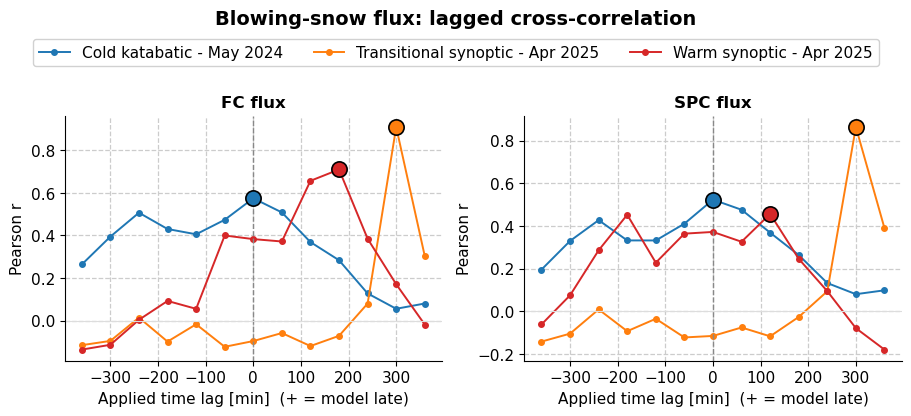


-- FC flux - best time lag --


,Event,dt [min],r (lag 0),best lag [min],best lag [steps],r (best),N
0,Cold katabatic - May 2024,60.0,0.574,0.0,0,0.574,38
1,Transitional synoptic - Apr 2025,60.0,-0.096,300.0,5,0.909,15
2,Warm synoptic - Apr 2025,60.0,0.382,180.0,3,0.709,21



-- SPC flux - best time lag --


,Event,dt [min],r (lag 0),best lag [min],best lag [steps],r (best),N
0,Cold katabatic - May 2024,60.0,0.523,0.0,0,0.523,38
1,Transitional synoptic - Apr 2025,60.0,-0.115,300.0,5,0.864,15
2,Warm synoptic - Apr 2025,60.0,0.372,120.0,2,0.456,22


In [11]:
LAG_MAX_STEPS = 6   # test +/- this many WRF output steps

# Best-lag summary table (console) + r-vs-lag curves
ru.print_bs_lag_summary(bs_events, max_steps=LAG_MAX_STEPS)
ru.plot_bs_lag_curves(bs_events, domain=DOMAIN, max_steps=LAG_MAX_STEPS, save=SAVE_PLOTS)
ru.show_tables(ru.bs_lag_tables(bs_events, max_steps=LAG_MAX_STEPS))

Saved: C:\Users\lory2\Desktop\tesi\wrf_notebooks\validation_plots\bs_lag_scatter_d04.png


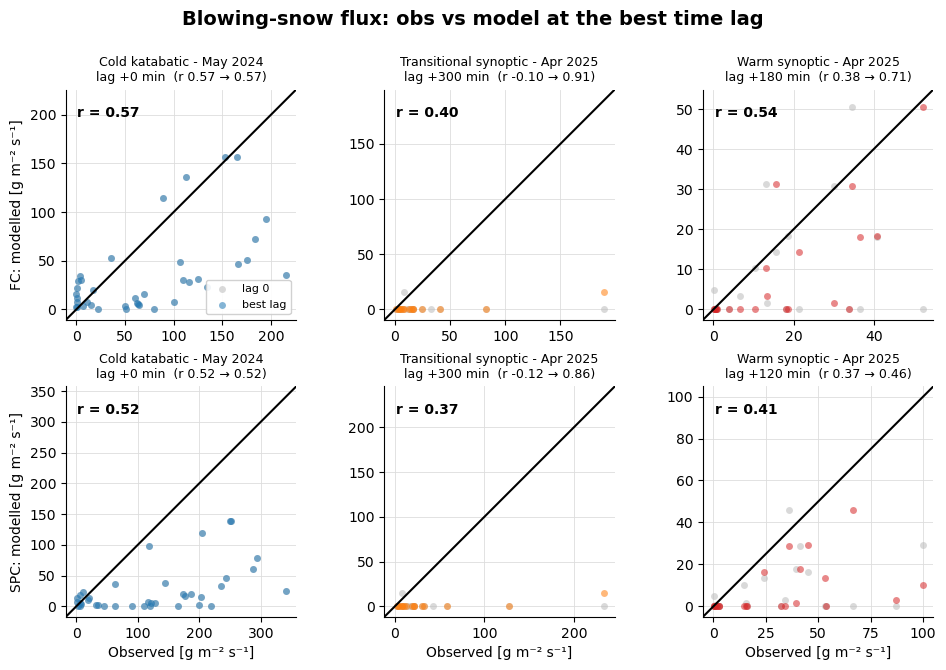

In [12]:
# Obs-vs-model scatter at each event's best lag (grey = zero lag)
ru.plot_bs_lag_scatter(bs_events, domain=DOMAIN, max_steps=LAG_MAX_STEPS, save=SAVE_PLOTS)

## 5. Ceilometer in-cloud backscatter vs WRF column blowing snow

In [13]:
ceilo_by_event = {key: ru.build_ceilometer(key, domain=DOMAIN) for key in RUN_KEYS}
for key, r in ceilo_by_event.items():
    print(f"{key}: WRF n={len(r['wrf'])}, ceilo valid={int(r['obs_h'].notna().sum())}")


c:\Users\lory2\Desktop\thesis_codes\04_cryowrf_validation\funcs_remote_obs.py:99: UserWarning: WARNING: missing_value not used since it
cannot be safely cast to variable data type
  bsc = np.asarray(nc.variables["backscatter"][:], float)  # (n_range, n_time)
c:\Users\lory2\Desktop\thesis_codes\04_cryowrf_validation\funcs_remote_obs.py:99: UserWarning: WARNING: missing_value not used since it
cannot be safely cast to variable data type
  bsc = np.asarray(nc.variables["backscatter"][:], float)  # (n_range, n_time)
c:\Users\lory2\Desktop\thesis_codes\04_cryowrf_validation\funcs_remote_obs.py:99: UserWarning: WARNING: missing_value not used since it
cannot be safely cast to variable data type
  bsc = np.asarray(nc.variables["backscatter"][:], float)  # (n_range, n_time)
c:\Users\lory2\Desktop\thesis_codes\04_cryowrf_validation\funcs_remote_obs.py:99: UserWarning: WARNING: missing_value not used since it
cannot be safely cast to variable data type
  bsc = np.asarray(nc.variables["backscatte

cold_kat: WRF n=45, ceilo valid=33
trans_syn: WRF n=20, ceilo valid=19
warm_syn: WRF n=24, ceilo valid=8


## 6. Fine-mesh wind vs AWS at instrument height

Saved: C:\Users\lory2\Desktop\tesi\wrf_notebooks\validation_plots\bs_finemesh_wind_d04.png


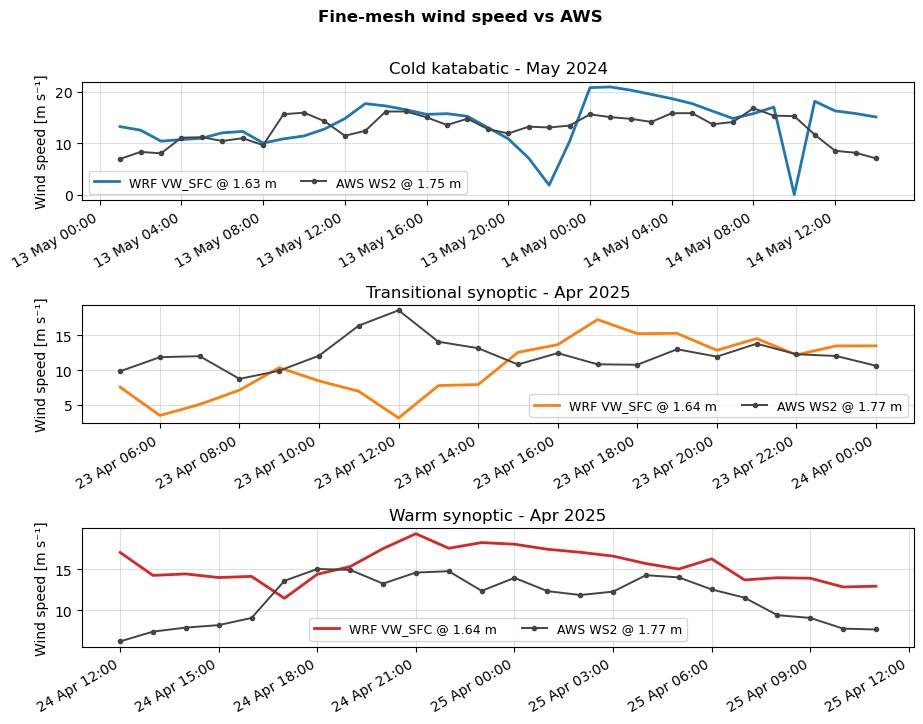

In [14]:
wind_by_event = {key: ru.build_wind(key, domain=DOMAIN) for key in RUN_KEYS}
ru.plot_wind(wind_by_event, domain=DOMAIN, save=SAVE_PLOTS)


## 7. Mass flux vs wind speed

Saved: C:\Users\lory2\Desktop\tesi\wrf_notebooks\validation_plots\flux_vs_wind_d04.png


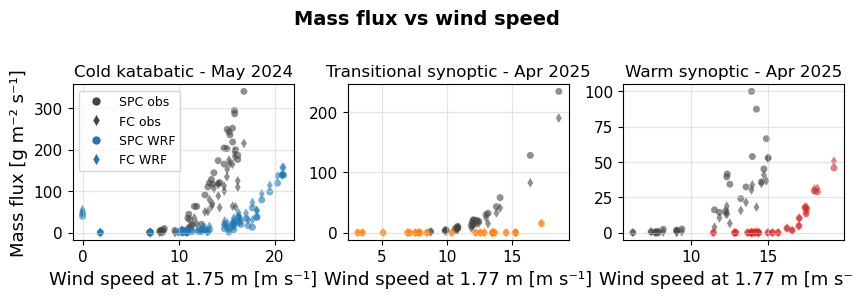

In [15]:
fw_by_event = {key: ru.build_flux_vs_wind(key, domain=DOMAIN) for key in RUN_KEYS}
ru.plot_flux_vs_wind(fw_by_event, domain=DOMAIN, save=SAVE_PLOTS)


## 8. Mass flux vs friction velocity

Observed u* from EddyPro, model `UST` and threshold friction velocity.

In [16]:
# ══════════════════════════════════════════════════════════════════════════════
#  Section 8. Mass flux vs friction velocity
#  Data: ru.build_flux_vs_ustar  (obs EddyPro u*, model UST + THRESHOLD_USTAR).
# ══════════════════════════════════════════════════════════════════════════════
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ── data (one dict per event) ───────────────────────────────────────────
fu_by_event = {key: ru.build_flux_vs_ustar(key, domain=DOMAIN) for key in RUN_KEYS}

# ── Style ────────────────────────────────────────────
FIGSIZE_PER_PANEL = (4.2, 4.0)      # (width, height) of each panel
COLOR_OBS    = "#222222"            # observation colour
MODEL_COLORS = {                    # model colour per event (key = RUN_KEY)
    "cold_kat":  "#1f77b4",
    "trans_syn": "#ff7f0e",
    "warm_syn":  "#d62728",
}
MODEL_COLOR_DEFAULT = "#1f77b4"
MARKER_SPC   = "o"                  # marker SPC
MARKER_FC    = "d"                  # marker FlowCapt
MARKER_SIZE  = 34                   # marker size
MARKER_ALPHA = 0.65                 # marker alpha
THR_LINESTYLE = "--"                # u* threshold line style
THR_LINEWIDTH = 1.5
THR_LABEL    = r"$u_{*,\mathrm{thr}}$ (model)"
TITLE_FS     = 12
LABEL_FS     = 12
TICK_FS      = 10
LEGEND_FS    = 8
GRID_ALPHA   = 0.4
LOGY         = False                # True -> log y axis
SUPTITLE     = "Snow mass flux vs friction velocity"
SAVE_FIG     = SAVE_PLOTS           # save png to ru.OUTPUT_DIR
SAVE_NAME    = f"flux_vs_ustar_{DOMAIN}.png"
DPI          = 180
# ──────────────────────────────────────────────────────────────────────────────

keys = list(fu_by_event.keys())
fig, axes = plt.subplots(
    1, len(keys),
    figsize=(FIGSIZE_PER_PANEL[0] * len(keys), FIGSIZE_PER_PANEL[1]),
    squeeze=False,
)

for j, key in enumerate(keys):
    r  = fu_by_event[key]
    d  = r["wrf"]
    ax = axes[0, j]
    mc = MODEL_COLORS.get(key, MODEL_COLOR_DEFAULT)

    # observations (black): SPC + FlowCapt vs observed u*
    ax.scatter(r["ust_obs"], r["spc_obs"], c=COLOR_OBS, marker=MARKER_SPC,
               s=MARKER_SIZE, alpha=MARKER_ALPHA, edgecolors="none")
    ax.scatter(r["ust_obs"], r["fc_obs"],  c=COLOR_OBS, marker=MARKER_FC,
               s=MARKER_SIZE, alpha=MARKER_ALPHA, edgecolors="none")
    # model (event colour): SPC + FlowCapt vs model UST
    ax.scatter(d["ust"], d["q_spc"], c=mc, marker=MARKER_SPC,
               s=MARKER_SIZE, alpha=MARKER_ALPHA, edgecolors="none")
    ax.scatter(d["ust"], d["Q_fc"],  c=mc, marker=MARKER_FC,
               s=MARKER_SIZE, alpha=MARKER_ALPHA, edgecolors="none")
    # model threshold friction velocity (event median)
    u_thr = float(np.nanmedian(d["thr"]))
    ax.axvline(u_thr, color=mc, ls=THR_LINESTYLE, lw=THR_LINEWIDTH)

    ax.set_title(r["label"], fontsize=TITLE_FS)
    ax.set_xlabel(r"Friction velocity $u_*$ [%s]" % ru.WS_UNIT, fontsize=LABEL_FS)
    ax.grid(True, alpha=GRID_ALPHA)
    ax.tick_params(labelsize=TICK_FS)
    if LOGY:
        ax.set_yscale("log")
    if j == 0:
        ax.set_ylabel(f"Mass flux [{ru.FLUX_UNIT}]", fontsize=LABEL_FS)
        handles = [
            Line2D([0], [0], marker=MARKER_SPC, color="w", markerfacecolor=COLOR_OBS, markersize=7, label="SPC obs"),
            Line2D([0], [0], marker=MARKER_FC,  color="w", markerfacecolor=COLOR_OBS, markersize=7, label="FC obs"),
            Line2D([0], [0], marker=MARKER_SPC, color="w", markerfacecolor=mc,        markersize=7, label="SPC model"),
            Line2D([0], [0], marker=MARKER_FC,  color="w", markerfacecolor=mc,        markersize=7, label="FC model"),
            Line2D([0], [0], color=mc, ls=THR_LINESTYLE, lw=THR_LINEWIDTH, label=THR_LABEL),
        ]
        ax.legend(handles=handles, fontsize=LEGEND_FS, loc="upper left")

fig.suptitle(SUPTITLE, fontsize=LABEL_FS + 1, fontweight="bold", y=1.02)
plt.tight_layout()
if SAVE_FIG:
    fig.savefig(os.path.join(ru.OUTPUT_DIR, SAVE_NAME), dpi=DPI, bbox_inches="tight")
plt.show()
plt.close(fig)


FileNotFoundError: [Errno 2] No such file or directory: 'Y:\\CRYOS\\Projects\\Antarctica\\PrincessElisabeth\\Season_2024-2025\\DATA\\processed\\SFC_DR\\Eddypro_output\\202405\\eddypro_May2024_full_output_2025-05-22T145422_adv.csv'

## 9. Snow density profile (top 8 layers)

Density = SN_VOLI·ρ_ice + SN_VOLW·ρ_water from the CRYOWRF multi-layer snow model, at PEA.

In [17]:
from netCDF4 import Dataset as _NC
import numpy as np

def extract_snow_density_profile(sim_key, domain=DOMAIN, n_top_layers=8):
    """
    Extract mean snow density profile from ice/water volume fractions.

    Density = SN_VOLI * rho_ice + SN_VOLW * rho_water
    where rho_ice=917, rho_water=1000 kg/m³

    Returns dict with:
        - times: list of timestamps
        - layer_idx: array of layer indices [0..n_top_layers-1]
        - profiles: (n_time, n_layers) array of density [kg/m³]
        - label: event label
        - color: event color
    """
    RHO_ICE = 917.0   # kg/m³
    RHO_WATER = 1000.0

    sim = ru.SIMULATIONS[sim_key]
    files = ru.fiv.get_wrf_files(domain=domain, input_dir=sim["sim_dir"])

    times = []
    all_profiles = []

    for fpath in files:
        try:
            with _NC(fpath) as nc:
                # Check for required variables
                if "SN_VOLI" not in nc.variables or "SN_VOLW" not in nc.variables:
                    continue

                # Read snow volume fractions
                # Shape: (time, layers=100, ny, nx)
                sn_voli = np.array(nc.variables["SN_VOLI"][:, :n_top_layers, :, :])
                sn_volw = np.array(nc.variables["SN_VOLW"][:, :n_top_layers, :, :])
                n_layers = sn_voli.shape[1]

                # Get lat/lon for interpolation to PEA
                la = np.array(nc.variables["XLAT"][0, :, :])
                lo = np.array(nc.variables["XLONG"][0, :, :])

                # Read time
                times_str = nc.variables["Times"][:]

                for t in range(len(times_str)):
                    time_str = "".join([c.decode() if isinstance(c, bytes) else c
                                       for c in times_str[t]])
                    time_obj = pd.to_datetime(time_str, format="%Y-%m-%d_%H:%M:%S")
                    times.append(time_obj)

                    # Extract top N layers, interpolate to PEA location
                    prof = []
                    for layer in range(n_layers):
                        # Get 2D field for this layer
                        voli_2d = sn_voli[t, layer, :, :]  # convert % to fraction
                        volw_2d = sn_volw[t, layer, :, :]

                        # Density = ice_fraction * rho_ice + water_fraction * rho_water
                        density_2d = voli_2d * RHO_ICE + volw_2d * RHO_WATER

                        # Interpolate to PEA
                        interp = ru.fiv._build_interp(la, lo, density_2d)
                        val = ru.fiv._interp_pt(interp, ru.fiv.PEA_LAT, ru.fiv.PEA_LON)
                        prof.append(float(val) if np.isfinite(val) else np.nan)

                    all_profiles.append(prof)
        except Exception as e:
            print(f"Warning: {fpath} - {e}")
            continue

    return {
        "label": sim["label"],
        "color": sim["color"],
        "times": times,
        "layer_idx": np.arange(n_top_layers),
        "profiles": np.array(all_profiles) if all_profiles else np.array([]),
    }

# Extract profiles for all events
sn_density = {}
for key in RUN_KEYS:
    print(f"Extracting snow density for {key}...", end=" ")
    sn_density[key] = extract_snow_density_profile(key, domain=DOMAIN, n_top_layers=8)
    if len(sn_density[key]["profiles"]) > 0:
        n_t = len(sn_density[key]['profiles'])
        n_l = sn_density[key]['profiles'].shape[1]
        print(f"{n_t} timesteps, {n_l} layers")
    else:
        print("no data")


Extracting snow density for cold_kat... 56 timesteps, 8 layers
Extracting snow density for trans_syn... 69 timesteps, 8 layers
Extracting snow density for warm_syn... 27 timesteps, 8 layers


### Mean density profile per event

In [18]:
import matplotlib.pyplot as plt

Saved: C:\Users\lory2\Desktop\tesi\wrf_notebooks\validation_plots/snow_density_profile_d04.png


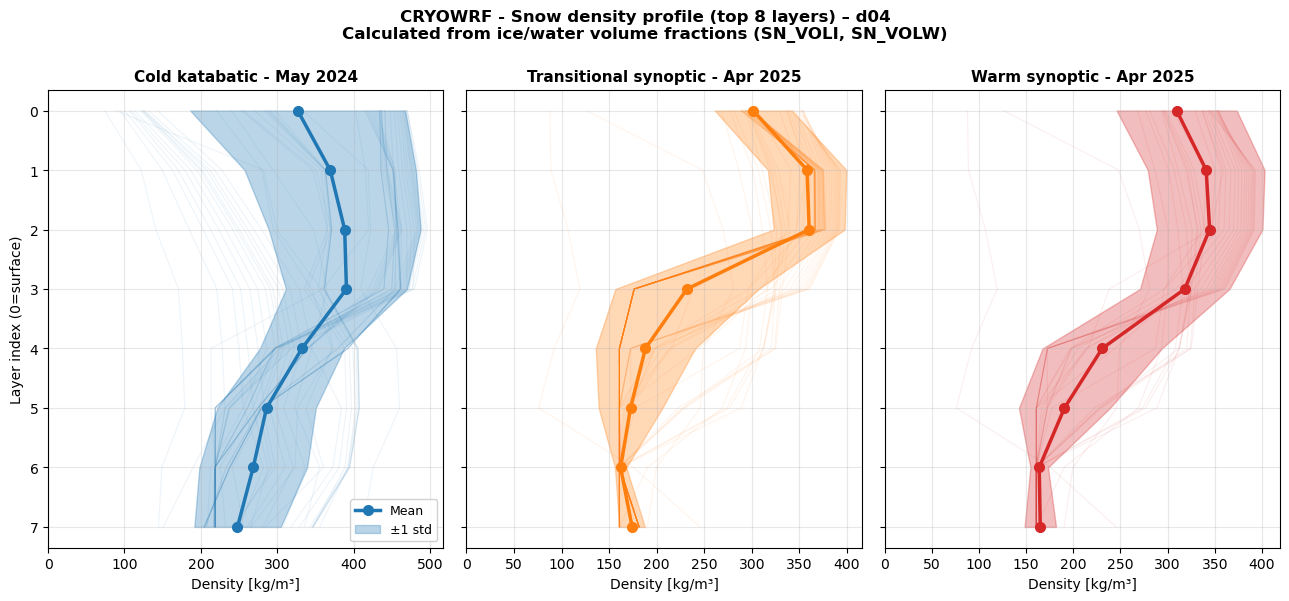

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(13, 6), sharey=True)

for ax, key in zip(axes, RUN_KEYS):
    r = sn_density[key]
    if len(r["profiles"]) == 0:
        ax.text(0.5, 0.5, "No data", ha="center", va="center",
                transform=ax.transAxes, fontsize=12)
        ax.set_title(r["label"], fontsize=11, fontweight="bold")
        continue

    # Compute mean and std along time axis
    mean_prof = np.nanmean(r["profiles"], axis=0)
    std_prof = np.nanstd(r["profiles"], axis=0)
    layers = r["layer_idx"]

    # Plot mean with shaded std band
    ax.plot(mean_prof, layers, "o-", color=r["color"], lw=2.5, ms=7, label="Mean", zorder=3)
    ax.fill_betweenx(layers, mean_prof - std_prof, mean_prof + std_prof,
                      color=r["color"], alpha=0.3, zorder=1, label="±1 std")

    # Plot individual profiles faintly
    for prof in r["profiles"]:
        ax.plot(prof, layers, color=r["color"], alpha=0.08, lw=0.8, zorder=0)

    ax.set_title(r["label"], fontsize=11, fontweight="bold")
    ax.set_xlabel("Density [kg/m³]", fontsize=10)
    ax.grid(True, alpha=0.3, which="both")
    ax.invert_yaxis()
    ax.set_xlim(left=0)
    if key == RUN_KEYS[0]:
        ax.legend(fontsize=9, loc="lower right", framealpha=0.9)

axes[0].set_ylabel("Layer index (0=surface)", fontsize=10)
fig.suptitle(f"CRYOWRF - Snow density profile (top 8 layers) – {DOMAIN}\n"
             f"Calculated from ice/water volume fractions (SN_VOLI, SN_VOLW)",
             fontsize=12, fontweight="bold", y=0.995)
plt.tight_layout()

if SAVE_PLOTS:
    fig_path = f"{ru.OUTPUT_DIR}/snow_density_profile_{DOMAIN}.png"
    plt.savefig(fig_path, dpi=ru.DPI, bbox_inches="tight")
    print(f"Saved: {fig_path}")

plt.show()
plt.close(fig)
